In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.collections import LineCollection
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.spatial import cKDTree

# 确保在 Notebook 中显示图片
%matplotlib inline

# 设置全局字体
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False # 处理负号显示问题

# 定义全局颜色
color1, color2, color3 = 'tab:red', 'tab:brown', 'tab:cyan'
color4, color5, color6 = 'tab:pink', 'tab:olive', 'tab:purple'

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
def load_csv_data(file_path):
    ''' 加载csv文件，返回字典 '''
    # 在ipynb中建议使用相对路径或绝对路径
    df = pd.read_csv(file_path)

    log = {
        "time": df["time"].to_numpy(),
        "pos": df[["pos_x", "pos_y", "pos_z"]].to_numpy(),
        "vel": df[["vel_x", "vel_y", "vel_z"]].to_numpy(),
        "att": df[["roll", "pitch", "yaw"]].to_numpy(),
        "ang": df[["roll_vel", "pitch_vel", "yaw_vel"]].to_numpy(),
        "thrust_z": df["thrust_z"].to_numpy(),
        "pos_des": df[["pos_xd", "pos_yd", "pos_zd"]].to_numpy(),
        "vel_des": df[["vel_xd", "vel_yd", "vel_zd"]].to_numpy(),
        "att_des": df[["roll_d", "pitch_d", "yaw_d"]].to_numpy(),
        "ang_des": df[["roll_vel_d", "pitch_vel_d", "yaw_vel_d"]].to_numpy(),
    }
    
    if 'force_x' in df.columns:
        log['force_controller'] = df[["force_x", "force_y", "force_z"]].to_numpy()
    if 'torque_x' in df.columns:
        log['torque_controller'] = df[["torque_x", "torque_y", "torque_z"]].to_numpy()
    if 'pos_xr' in df.columns:
        log["pos_ref"] = df[["pos_xr", "pos_yr", "pos_zr"]].to_numpy()
        log["vel_ref"] = df[["vel_xr", "vel_yr", "vel_zr"]].to_numpy()
        
    return log

def load_npz_data(file_path):
    data = np.load(file_path)
    log = {}
    if 'kx' in data:
        log["kx"] = [kx.reshape(3, 6) for kx in data['kx']]
        log["kr"] = [kr.reshape(3, 3) for kr in data['kr']]
        log["theta"] = [theta.reshape(6, 3) for theta in data['theta']]
    return log

In [3]:
def set_axes_equal(ax):
    """设置3D坐标轴等比例缩放"""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    max_range = max(abs(x_limits[1] - x_limits[0]), 
                    abs(y_limits[1] - y_limits[0]), 
                    abs(z_limits[1] - z_limits[0]))
    x_mid, y_mid, z_mid = np.mean(x_limits), np.mean(y_limits), np.mean(z_limits)
    ax.set_xlim3d([x_mid - max_range/2, x_mid + max_range/2])
    ax.set_ylim3d([y_mid - max_range/2, y_mid + max_range/2])
    ax.set_zlim3d([z_mid - max_range/2, z_mid + max_range/2])

def compute_segmented_rms(signal, start_index=2000, segment_length=4000):
    valid_data = signal[start_index:, :]
    total_len = valid_data.shape[0]
    num_segments = (total_len // segment_length) + (1 if total_len % segment_length else 0)
    xy_rms_list, xyz_rms_list = [], []
    for i in range(num_segments):
        idx1, idx2 = i * segment_length, min((i + 1) * segment_length, total_len)
        segment = valid_data[idx1:idx2, :]
        xy_rms_list.append(np.sqrt(np.mean(np.sum(segment[:, :2]**2, axis=1))))
        xyz_rms_list.append(np.sqrt(np.mean(np.sum(segment**2, axis=1))))
    return xy_rms_list, xyz_rms_list

In [4]:
def plot_pos_att(log):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    titles = ['X-Axis', 'Y-Axis', 'Z-Axis']
    
    for i in range(3):
        # Position subplots
        ax = axes[0, i]
        ax.plot(log['time'], log['pos'][:, i], label='Actual', color=color1)
        ax.plot(log['time'], log['pos_des'][:, i], '--', label='Desired', color=color2)
        if 'pos_ref' in log:
            ax.plot(log['time'], log['pos_ref'][:, i], ':', label='Ref', color=color3)
        ax.set_title(f'Position {titles[i]}')
        ax.grid(True, alpha=0.3)
        ax.legend()

        # Velocity subplots
        ax_v = axes[1, i]
        ax_v.plot(log['time'], log['vel'][:, i], label='Vel', color=color1)
        ax_v.plot(log['time'], log['vel_des'][:, i], '--', label='Vel Des', color=color2)
        ax_v.set_title(f'Velocity {titles[i]}')
        ax_v.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()

def plot_2d_trajectory_with_time(pos, pos_des=None):
    n_points = pos.shape[0]
    time_idx = np.linspace(0, 1, n_points)
    points = pos[:, :2].reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    norm = Normalize(0, 1)
    cmap = plt.get_cmap('plasma')
    lc = LineCollection(segments, colors=cmap(norm(time_idx[:-1])), linewidths=2.5)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.add_collection(lc)
    if pos_des is not None:
        ax.plot(pos_des[:, 0], pos_des[:, 1], '--', color='gray', alpha=0.6, label='Reference')
    
    ax.autoscale()
    ax.set_aspect('equal')
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Time Progress')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def plot_rms_comparison(xy_rms, xyz_rms):
    x = np.arange(len(xy_rms))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, xy_rms, width, label='XY Plane RMS', color='#3498db')
    ax.bar(x + width/2, xyz_rms, width, label='XYZ Space RMS', color='#e74c3c')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Seg {i+1}' for i in range(len(xy_rms))])
    ax.set_ylabel('Error (m)')
    ax.legend(); plt.grid(axis='y', alpha=0.3)
    plt.show()

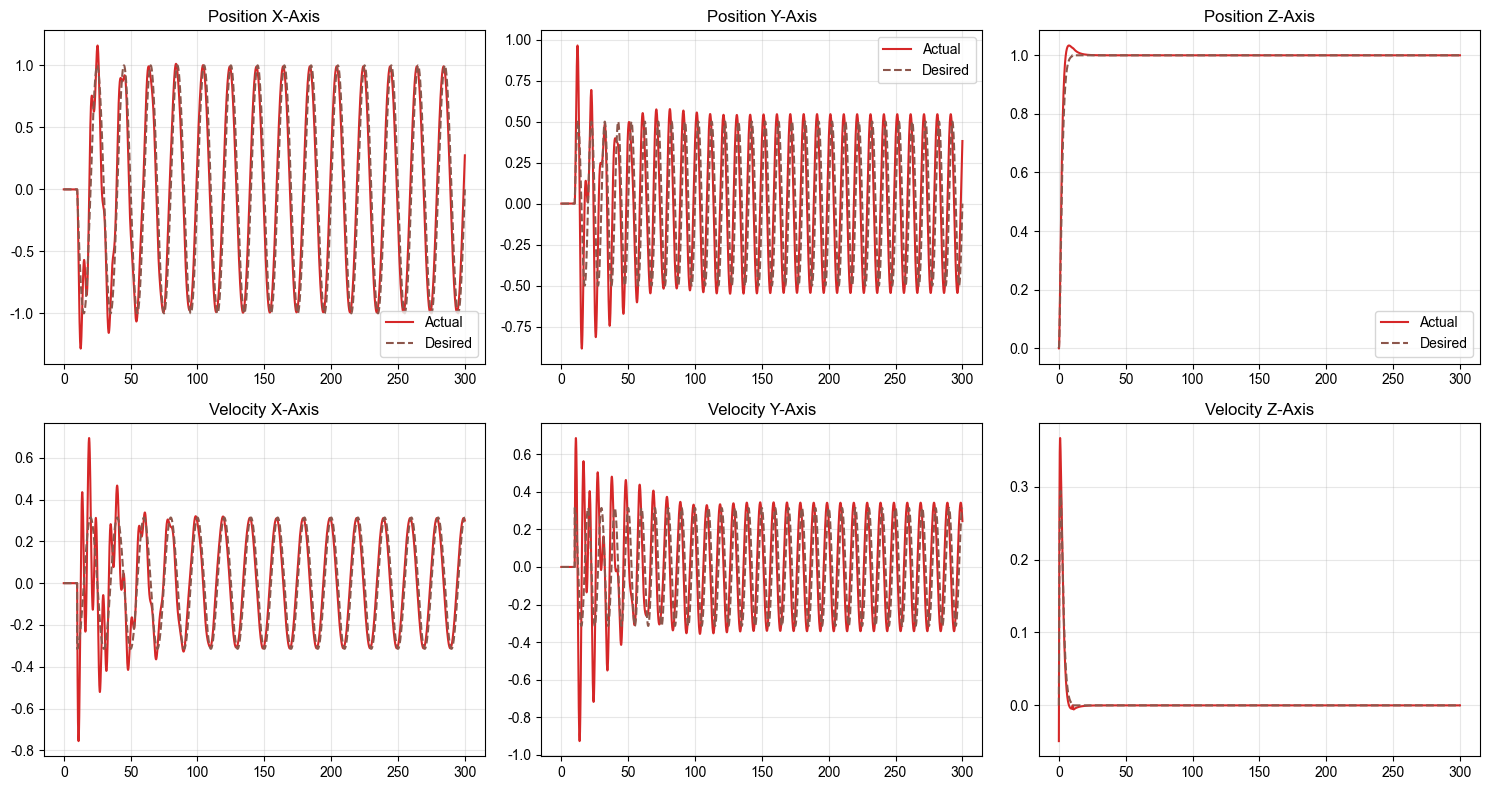

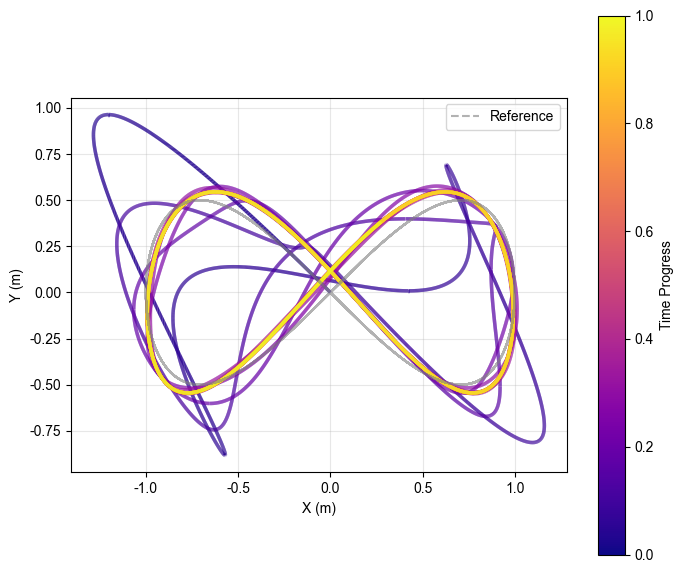

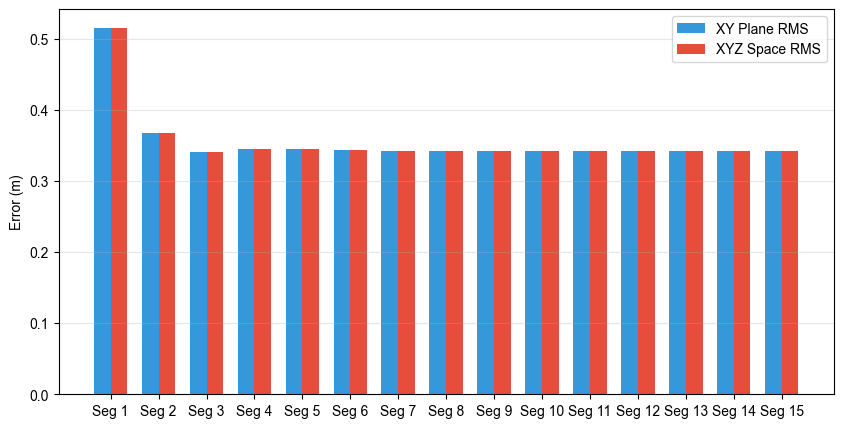

In [5]:
# --- 设置路径 ---
# 获取当前路径（在Notebook中通常为脚本所在目录）
current_dir = os.getcwd() 
csv_file = os.path.join(current_dir, 'Data/RL_MRAC_flare.csv')

if os.path.exists(csv_file):
    # 1. 加载数据
    log = load_csv_data(csv_file)
    
    # 2. 绘制位置姿态
    plot_pos_att(log)
    
    # 3. 绘制2D轨迹
    plot_2d_trajectory_with_time(log['pos'], log["pos_des"])
    
    # 4. 计算并绘制RMS
    error_signal = log['pos'] - log['pos_des']
    xy_rms, xyz_rms = compute_segmented_rms(error_signal, start_index=2000, segment_length=4000)
    plot_rms_comparison(xy_rms, xyz_rms)
else:
    print(f"Error: File not found at {csv_file}")